# Step 1 playground: synthetic data in DuckDB
Run top to bottom. Kernel: the project `.venv` (needs `ipykernel`).

In [1]:
import os, sys
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "playground" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import duckdb, pandas as pd
pd.set_option("display.width", 160)
DB = "data/warehouse.duckdb"
print("project root:", ROOT)

project root: /Users/xuhui/Documents/VScode/AI_pricing_system


## 1. (Optional) Regenerate the data
Deletes and recreates the file. Same seed = same data.

In [2]:
from jobs.data_gen.generate import write
write(DB, seed=42)

{'weeks': 13,
 'products': 128,
 'stores': 13,
 'sales': 139776,
 'price_history': 4608,
 'inventory': 621,
 'clearance_candidates': 624,
 'business_rules': 205,
 'seed_manifest': 5}

## 2. Tables and row counts

In [3]:
con = duckdb.connect(DB, read_only=True)
tables = [r[0] for r in con.sql("SHOW TABLES").fetchall()]
pd.DataFrame({t: [con.sql(f"SELECT count(*) FROM {t}").fetchone()[0]] for t in tables}, index=["rows"]).T

,rows
business_rules,205
clearance_candidates,624
inventory,621
price_history,4608
products,128
sales,139776
seed_manifest,5
stores,13
weeks,13


## 3. Peek at each table

In [4]:
for t in tables:
    print(f"--- {t}")
    display(con.sql(f"SELECT * FROM {t} LIMIT 5").df())

--- business_rules


,week,sku,pack_type,pack_qty,price_floor,max_markdown_pct,rule_version
0,2026-W34,100002,Single,1,22.34,0.5,SAP-R-2026-W34
1,2026-W34,100004,Single,1,29.04,0.5,SAP-R-2026-W34
2,2026-W34,100006,Single,1,23.32,0.5,SAP-R-2026-W34
3,2026-W34,100011,Single,1,21.24,0.5,SAP-R-2026-W34
4,2026-W34,100013,Single,1,12.30,0.5,SAP-R-2026-W34


--- clearance_candidates


,week,sku,pack_type,pack_qty,region,current_price
0,2026-W34,100002,Single,1,VIC,36.99
1,2026-W34,100002,Single,1,NSW,36.99
2,2026-W34,100002,Single,1,QLD,36.99
3,2026-W34,100004,Single,1,VIC,60.99
4,2026-W34,100004,Single,1,NSW,60.99


--- inventory


...

,week,sku,pack_type,pack_qty,issue,detail
0,2026-W39,100002,Single,1,MISSING_RULE,no floor in rules snapshot
1,2026-W39,100004,Single,1,MISSING_RULE,no floor in rules snapshot
2,2026-W39,100006,Single,1,FLOOR_ABOVE_PRICE,floor exceeds current price
3,2026-W39,100007,Single,1,ZERO_INVENTORY,on_hand = 0 in all regions
4,2026-W39,999999,Single,1,NOT_IN_PRODUCTS,candidate has no product master


--- stores


,store_id,region,price_zone
0,VIC01,VIC,VIC_METRO
1,VIC02,VIC,VIC_METRO
2,VIC03,VIC,VIC_METRO
3,VIC04,VIC,VIC_REGIONAL
4,VIC05,VIC,VIC_REGIONAL


--- weeks


,week,week_start,status
0,2026-W27,2026-06-29,history
1,2026-W28,2026-07-06,history
2,2026-W29,2026-07-13,history
3,2026-W30,2026-07-20,history
4,2026-W31,2026-07-27,history


## 4. Planted issues (seed_manifest)

In [5]:
con.sql("SELECT * FROM seed_manifest").df()

,week,sku,pack_type,pack_qty,issue,detail
0,2026-W39,100002,Single,1,MISSING_RULE,no floor in rules snapshot
1,2026-W39,100004,Single,1,MISSING_RULE,no floor in rules snapshot
2,2026-W39,100006,Single,1,FLOOR_ABOVE_PRICE,floor exceeds current price
3,2026-W39,100007,Single,1,ZERO_INVENTORY,on_hand = 0 in all regions
4,2026-W39,999999,Single,1,NOT_IN_PRODUCTS,candidate has no product master


## 5. Candidates joined with rules (NULL floor = missing rule)

In [6]:
con.sql('''
SELECT c.sku, c.pack_type, c.pack_qty, c.region, c.current_price, r.price_floor, r.max_markdown_pct, p.cost
FROM clearance_candidates c
LEFT JOIN business_rules r USING (week, sku, pack_qty)
LEFT JOIN products p USING (sku, pack_qty)
WHERE c.week = '2026-W39' AND c.region = 'VIC' ORDER BY c.sku, c.pack_qty
''').df()

,sku,pack_type,pack_qty,region,current_price,price_floor,max_markdown_pct,cost
0,100002,Single,1,VIC,23.85,NaN,NaN,21.28
1,100002,Multipack,6,VIC,221.94,130.04,0.5,123.85
2,100004,Single,1,VIC,35.63,NaN,NaN,27.66
3,100006,Single,1,VIC,24.72,31.35,0.5,22.21
4,100006,Multipack,6,VIC,258.94,135.72,0.5,129.26
5,100007,Single,1,VIC,14.62,13.00,0.5,12.38
6,100007,Multipack,6,VIC,104.66,75.65,0.5,72.05
7,100008,Single,1,VIC,8.40,5.04,0.5,4.80
8,100008,Multipack,6,VIC,56.14,29.34,0.5,27.94
9,100011,Single,1,VIC,23.50,21.24,0.5,20.23


## 6. Check each planted issue shows up in the data

In [7]:
print("Missing rule:");        display(con.sql("SELECT c.sku, c.pack_qty FROM clearance_candidates c LEFT JOIN business_rules r USING (week, sku, pack_qty) WHERE c.week='2026-W39' AND r.sku IS NULL AND c.region='VIC'").df())
print("Floor above price:");   display(con.sql("SELECT c.sku, c.pack_qty, c.current_price, r.price_floor FROM clearance_candidates c JOIN business_rules r USING (week, sku, pack_qty) WHERE c.week='2026-W39' AND r.price_floor > c.current_price AND c.region='VIC'").df())
print("Zero inventory:");      display(con.sql("SELECT * FROM inventory WHERE week='2026-W39' AND on_hand = 0").df())
print("No product master:");   display(con.sql("SELECT c.sku, c.pack_qty FROM clearance_candidates c LEFT JOIN products p USING (sku, pack_qty) WHERE c.week='2026-W39' AND p.sku IS NULL AND c.region='VIC'").df())

Missing rule:


,sku,pack_qty
0,100002,1
1,100004,1
2,999999,1


Floor above price:


,sku,pack_qty,current_price,price_floor
0,100006,1,24.72,31.35


Zero inventory:


,week,sku,pack_type,pack_qty,region,on_hand
0,2026-W39,100007,Single,1,VIC,0
1,2026-W39,100007,Single,1,NSW,0
2,2026-W39,100007,Single,1,QLD,0


No product master:


,sku,pack_qty
0,999999,1


## 6b. All weeks are stored
History W27-W33, published clearance W34-W38, open week W39.

In [8]:
display(con.sql("SELECT * FROM weeks").df())
con.sql('''SELECT week, count(DISTINCT sku) AS skus, count(*) AS rows FROM clearance_candidates GROUP BY 1 ORDER BY 1''').df()

,week,week_start,status
0,2026-W27,2026-06-29,history
1,2026-W28,2026-07-06,history
2,2026-W29,2026-07-13,history
3,2026-W30,2026-07-20,history
4,2026-W31,2026-07-27,history
5,2026-W32,2026-08-03,history
6,2026-W33,2026-08-10,history
7,2026-W34,2026-08-17,published
8,2026-W35,2026-08-24,published
9,2026-W36,2026-08-31,published


,week,skus,rows
0,2026-W34,20,60
1,2026-W35,25,84
2,2026-W36,31,102
3,2026-W37,35,114
4,2026-W38,37,126
5,2026-W39,41,138


## 6c. Constraint: price this week <= last week (same SKU, same region)
Must return 0 violations. W33 is the regular price, so a SKU's first clearance week is compared with it.

In [9]:
viol = con.sql('''
SELECT * FROM (
  SELECT week, sku, pack_qty, region, price, lag(price) OVER (PARTITION BY sku, pack_qty, region ORDER BY week) AS prev
  FROM price_history WHERE week >= '2026-W33')
WHERE prev IS NOT NULL AND price > prev + 1e-9''').df()
print("violations:", len(viol)); viol.head()

violations: 0


,week,sku,pack_qty,region,price,prev


In [10]:
# one item's markdown path (region VIC), Single pack
sku = con.sql("SELECT sku FROM clearance_candidates WHERE week='2026-W34' AND pack_qty=1 LIMIT 1").fetchone()[0]
con.sql(f"SELECT week, sku, pack_type, pack_qty, price, is_clearance FROM price_history WHERE sku='{sku}' AND pack_qty=1 AND region='VIC' ORDER BY week").df()

,week,sku,pack_type,pack_qty,price,is_clearance
0,2026-W27,100002,Single,1,36.99,False
1,2026-W28,100002,Single,1,36.99,False
2,2026-W29,100002,Single,1,33.29,False
3,2026-W30,100002,Single,1,40.69,False
4,2026-W31,100002,Single,1,36.99,False
5,2026-W32,100002,Single,1,33.29,False
6,2026-W33,100002,Single,1,36.99,False
7,2026-W34,100002,Single,1,32.18,True
8,2026-W35,100002,Single,1,29.05,True
9,2026-W36,100002,Single,1,27.56,True


## 6d. Multipacks
Different pack sizes share the same `sku`; `pack_type` (Single / Multipack) and `pack_qty` (units in the pack) tell them apart. Constraint: pack price / pack_qty >= the Single's price, same week and region. Must return 0 violations.

In [11]:
display(con.sql("SELECT pack_type, pack_qty, count(*) AS rows, count(DISTINCT sku) AS distinct_sku_ids FROM products GROUP BY 1, 2 ORDER BY 2").df())
# the same sku id appears once per pack size
example = con.sql("SELECT sku FROM products WHERE pack_qty = 12 LIMIT 1").fetchone()[0]
display(con.sql(f"SELECT sku, pack_type, pack_qty, name, base_price, cost FROM products WHERE sku = '{example}' ORDER BY pack_qty").df())
viol = con.sql('''
SELECT pk.week, pk.sku, pk.pack_qty, pk.region, pk.price/pk.pack_qty AS unit_price, sg.price AS single_price
FROM price_history pk
JOIN price_history sg ON sg.sku = pk.sku AND sg.pack_qty = 1 AND sg.region = pk.region AND sg.week = pk.week
WHERE pk.pack_qty > 1 AND pk.week >= '2026-W34' AND pk.price/pk.pack_qty < sg.price - 1e-9''').df()
print("violations:", len(viol))

,pack_type,pack_qty,rows,distinct_sku_ids
0,Single,1,100,100
1,Multipack,6,20,20
2,Multipack,12,8,8


,sku,pack_type,pack_qty,name,base_price,cost
0,100020,Single,1,Stonefield White 020,17.99,9.45
1,100020,Multipack,12,Stonefield White 020 12-pack,215.88,110.00


violations: 0


In [12]:
# one item across its pack sizes: per-item price by week (region VIC)
sku = con.sql("SELECT sku FROM price_history WHERE pack_qty = 6 AND is_clearance LIMIT 1").fetchone()[0]
con.sql(f'''
SELECT week, pack_type, pack_qty, price AS pack_price, round(price / pack_qty, 2) AS unit_price
FROM price_history WHERE sku = '{sku}' AND region = 'VIC' AND week >= '2026-W33'
ORDER BY week, pack_qty''').df()

,week,pack_type,pack_qty,pack_price,unit_price
0,2026-W33,Single,1,60.99,60.99
1,2026-W33,Multipack,6,365.94,60.99
2,2026-W34,Single,1,58.08,58.08
3,2026-W34,Multipack,6,365.94,60.99
4,2026-W35,Single,1,54.02,54.02
5,2026-W35,Multipack,6,352.02,58.67
6,2026-W36,Single,1,46.81,46.81
7,2026-W36,Multipack,6,312.78,52.13
8,2026-W37,Single,1,40.24,40.24
9,2026-W37,Multipack,6,285.36,47.56


## 6e. Floors and max markdown respected in clearance weeks (0 violations each)

In [13]:
print("below floor:", con.sql('''SELECT count(*) FROM price_history h JOIN business_rules r ON r.sku=h.sku AND r.pack_qty=h.pack_qty AND r.week=h.week WHERE h.is_clearance AND h.price < r.price_floor - 1e-9''').fetchone()[0])
print("beyond max markdown:", con.sql('''SELECT count(*) FROM price_history h JOIN business_rules r ON r.sku=h.sku AND r.pack_qty=h.pack_qty AND r.week=h.week JOIN products p ON p.sku=h.sku AND p.pack_qty=h.pack_qty WHERE h.is_clearance AND h.price < p.base_price*(1-r.max_markdown_pct) - 0.01''').fetchone()[0])

below floor: 0
beyond max markdown: 0


## 7. Sales behaviour: price vs units for one SKU
Lower weekly price should give higher units (elasticity is negative).

,wk,units,avg_price
0,2026-06-29,145.0,241.37
1,2026-07-06,241.0,190.37
2,2026-07-13,180.0,254.96
3,2026-07-20,147.0,241.37
4,2026-07-27,151.0,237.97
5,2026-08-03,128.0,261.76
6,2026-08-10,139.0,237.97
7,2026-08-17,146.0,237.97
8,2026-08-24,159.0,237.97
9,2026-08-31,189.0,233.44


<Axes: title={'center': 'SKU 100000: weekly price vs units'}, xlabel='avg_price', ylabel='units'>

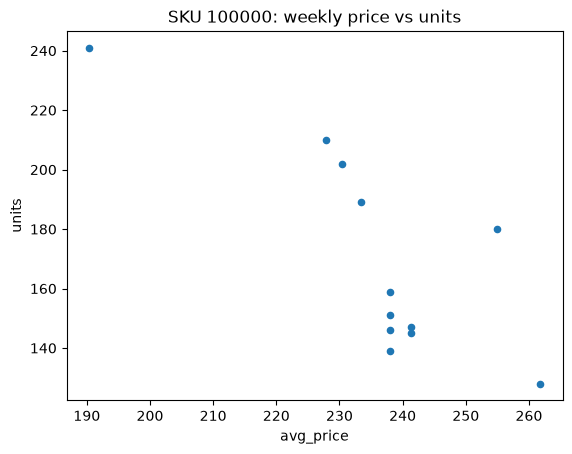

In [15]:
wk = con.sql('''
SELECT date_trunc('week', sale_date) AS wk, sum(units) AS units, round(avg(price),2) AS avg_price
FROM sales WHERE sku = '100000' GROUP BY 1 ORDER BY 1
''').df()
display(wk)
wk.plot(x="avg_price", y="units", kind="scatter", title="SKU 100000: weekly price vs units")

## 8. Through the WarehouseClient (what services will use)

In [16]:
from shared.warehouse import get_warehouse
wh = get_warehouse()          # reads env vars; defaults to DuckDB read-only
cands = wh.get_candidates("2026-W39")
print("candidate rows:", len(cands), "| distinct SKUs:", len({c['sku'] for c in cands}))
print("rules:", len(wh.get_rules("2026-W39")))
skus = sorted({c["sku"] for c in cands})[:3]
print("sales rows (VIC):", len(wh.get_sales_history(skus, "VIC")))
print("inventory rows:", len(wh.get_inventory(skus, "2026-W39")))
pd.DataFrame(cands).head()

candidate rows: 135 | distinct SKUs: 40
rules: 43
sales rows (VIC): 504
inventory rows: 15


,week,sku,pack_type,pack_qty,brand,category,name,base_price,cost,current_price,region
0,2026-W39,100002,Single,1,Larkspur,Spirits,Larkspur Spirits 002,36.99,21.28,22.34,NSW
1,2026-W39,100002,Single,1,Larkspur,Spirits,Larkspur Spirits 002,36.99,21.28,23.77,QLD
2,2026-W39,100002,Single,1,Larkspur,Spirits,Larkspur Spirits 002,36.99,21.28,23.85,VIC
3,2026-W39,100002,Multipack,6,Larkspur,Spirits,Larkspur Spirits 002 6-pack,221.94,123.85,221.94,NSW
4,2026-W39,100002,Multipack,6,Larkspur,Spirits,Larkspur Spirits 002 6-pack,221.94,123.85,221.94,QLD


## 9. Determinism check
Same seed must give identical data.

In [17]:
import tempfile
a, b = tempfile.mktemp(suffix=".duckdb"), tempfile.mktemp(suffix=".duckdb")
write(a, seed=7); write(b, seed=7)
from shared.warehouse import DuckDBWarehouse
print("identical:", DuckDBWarehouse(a).get_rules("2026-W39") == DuckDBWarehouse(b).get_rules("2026-W39"))

identical: True


In [18]:
con.close()